In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**EDA and Data Cleaning**

In [28]:
# Load the data from the CSV file

df_demo = pd.read_csv('raw/df_final_demo.csv')
df_wd1 = pd.read_csv('raw/df_final_web_data_pt_1.csv')
df_wd2 = pd.read_csv('raw/df_final_web_data_pt_2.csv')
df_exp = pd.read_csv('raw/df_final_experiment_clients.csv')    

**Experiment Roster**

-- *client_id*: Every client's unique ID.

-- *variation*: Indicates if a client was part of the experiment.


In [29]:
df_exp.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [30]:
df_exp.shape # There are 70609 rows and 2 columns in the experiment roster dataset.

(70609, 2)

In [31]:
df_exp.isna().sum() # There are 20109 missing values in the Variation column.

client_id        0
Variation    20109
dtype: int64

In [32]:
#df_exp.fillna('Control', inplace=True) # Fill missing values with 'Control'. Because we don't know which variation they belong to,

# Fill missing values with 'Control'. Because we don't know which variation they belong to, 
# we will assume they are aware of traditional online process, so we will fill them with 'Control'.    

In [33]:
df_exp.groupby('Variation')['client_id'].count().reset_index()

,Variation,client_id
0,Control,23532
1,Test,26968


But if we fill with Control, 'Test' (B) version will outperform the version 'Control' (A). See the output below:

-- So we gonna drop the null values. 

	Variation	client_id

0	Control			43641

1	Test			26968

In [34]:
df_exp.dropna(inplace=True) # Drop rows with missing values in the Variation column.

**demographics**

In [35]:
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [36]:
df_demo.shape

(70609, 9)

In [37]:
df_demo.isna().sum() # There are few missing values in the demographics dataset.

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [38]:
df_demo.dropna(inplace=True) # Drop rows with missing values in the demographics dataset.

In [39]:
df_demo.info()

<class 'pandas.DataFrame'>
Index: 70594 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70594 non-null  int64  
 1   clnt_tenure_yr    70594 non-null  float64
 2   clnt_tenure_mnth  70594 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70594 non-null  str    
 5   num_accts         70594 non-null  float64
 6   bal               70594 non-null  float64
 7   calls_6_mnth      70594 non-null  float64
 8   logons_6_mnth     70594 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 5.4 MB


In [40]:
# Merge the experiment roster with the demographics dataset on client_id.
df = pd.merge(df_exp, df_demo, on='client_id', how='inner') 
df.head()

,client_id,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,8320017,Test,22.0,274.0,34.5,M,2.0,36001.90,5.0,8.0
2,4033851,Control,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0
3,1982004,Test,6.0,80.0,44.5,U,2.0,30231.76,1.0,4.0
4,9294070,Control,5.0,70.0,29.0,U,2.0,34254.54,0.0,3.0


In [41]:
df = df.rename(columns={'gendr' :'gender'})
df.head()

,client_id,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,8320017,Test,22.0,274.0,34.5,M,2.0,36001.90,5.0,8.0
2,4033851,Control,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0
3,1982004,Test,6.0,80.0,44.5,U,2.0,30231.76,1.0,4.0
4,9294070,Control,5.0,70.0,29.0,U,2.0,34254.54,0.0,3.0


In [42]:
df.client_id.duplicated().sum() # Just to make sure! There are no duplicate client_id in the merged dataset.

np.int64(0)

In [43]:
df.gender.unique()

<StringArray>
['U', 'M', 'F', 'X']
Length: 4, dtype: str

In [44]:
df.gender.value_counts()

gender
U    17280
M    16947
F    16258
X        2
Name: count, dtype: int64

In [45]:
df.gender = df.gender.replace({'U' : 'Unknown', 'X': 'Female',  'M': 'Male', 'F': 'Female'}) # Replace 'U' with 'Unknown' and 'X' with 'Female' in the gender column.

df.head()

,client_id,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,5.0,64.0,79.0,Unknown,2.0,189023.86,1.0,4.0
1,8320017,Test,22.0,274.0,34.5,Male,2.0,36001.90,5.0,8.0
2,4033851,Control,12.0,149.0,63.5,Male,2.0,142642.26,5.0,8.0
3,1982004,Test,6.0,80.0,44.5,Unknown,2.0,30231.76,1.0,4.0
4,9294070,Control,5.0,70.0,29.0,Unknown,2.0,34254.54,0.0,3.0


In [46]:
df = df.drop(columns=['clnt_tenure_yr'])   # Drop the clnt_tenure_yr column because it is redundant with clnt_tenure_mnth.

cols_to_convert = ["clnt_age", "clnt_tenure_mnth", "num_accts", "calls_6_mnth", "logons_6_mnth"]

for col in cols_to_convert:
    df[col] = df[col].astype(int)

df.head()

,client_id,Variation,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,64,79,Unknown,2,189023.86,1,4
1,8320017,Test,274,34,Male,2,36001.90,5,8
2,4033851,Control,149,63,Male,2,142642.26,5,8
3,1982004,Test,80,44,Unknown,2,30231.76,1,4
4,9294070,Control,70,29,Unknown,2,34254.54,0,3


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50487 entries, 0 to 50486
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         50487 non-null  int64  
 1   Variation         50487 non-null  str    
 2   clnt_tenure_mnth  50487 non-null  int64  
 3   clnt_age          50487 non-null  int64  
 4   gender            50487 non-null  str    
 5   num_accts         50487 non-null  int64  
 6   bal               50487 non-null  float64
 7   calls_6_mnth      50487 non-null  int64  
 8   logons_6_mnth     50487 non-null  int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 3.5 MB


In [48]:
df.describe()

,client_id,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,5.048700e+04,50487.000000,50487.000000,50487.000000,5.048700e+04,50487.000000,50487.000000
mean,5.006180e+06,150.416365,47.058451,2.254580,1.495168e+05,3.093272,6.131856
std,2.877445e+06,81.945403,15.528092,0.533675,3.020390e+05,2.188009,2.175441
min,5.550000e+02,33.000000,17.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,2.515688e+06,82.000000,33.000000,2.000000,3.987718e+04,1.000000,4.000000
50%,5.025043e+06,136.000000,48.000000,2.000000,6.573433e+04,3.000000,6.000000
75%,7.477922e+06,192.000000,59.000000,2.000000,1.399583e+05,5.000000,8.000000
max,9.999832e+06,669.000000,96.000000,7.000000,1.632004e+07,6.000000,9.000000


Answered the following questions about demographics:

-- Who are the primary clients using this online process?

-- Are the primary clients younger or older, new or long-standing?

-- Carried out a client behaviour analysis to answer any additional relevant questions you think are important.


In [49]:
df.clnt_age.describe()

count    50487.000000
mean        47.058451
std         15.528092
min         17.000000
25%         33.000000
50%         48.000000
75%         59.000000
max         96.000000
Name: clnt_age, dtype: float64

In [50]:
from functions import age_group

In [51]:
age_groups = df['clnt_age'].apply(age_group)
df['age_group'] = age_groups
df.head()

,client_id,Variation,clnt_tenure_mnth,clnt_age,gender,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group
0,9988021,Test,64,79,Unknown,2,189023.86,1,4,Oldie
1,8320017,Test,274,34,Male,2,36001.90,5,8,Adult
2,4033851,Control,149,63,Male,2,142642.26,5,8,Senior
3,1982004,Test,80,44,Unknown,2,30231.76,1,4,Adult
4,9294070,Control,70,29,Unknown,2,34254.54,0,3,Younger


In [52]:
(df.groupby('age_group')['client_id'].count()).reset_index()

,age_group,client_id
0,Adult,18236
1,Oldie,2943
2,Senior,19659
3,Younger,9649


Seniors are the most active users between age 50 - 70 yrs old.

<function matplotlib.pyplot.show(close=None, block=None)>

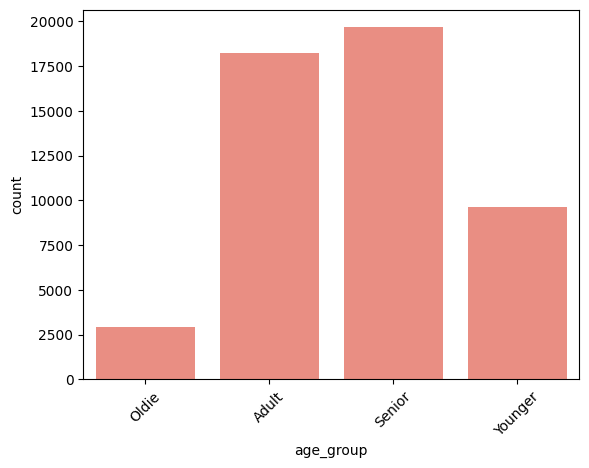

In [53]:
sns.countplot(x='age_group',  data=df, color='salmon')
plt.xticks(rotation=45)
plt.tight_layout
plt.show

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
round(df.groupby('age_group')['clnt_tenure_mnth'].mean().reset_index(),2)

,age_group,clnt_tenure_mnth
0,Adult,144.12
1,Oldie,204.90
2,Senior,167.49
3,Younger,110.93


<function matplotlib.pyplot.show(close=None, block=None)>

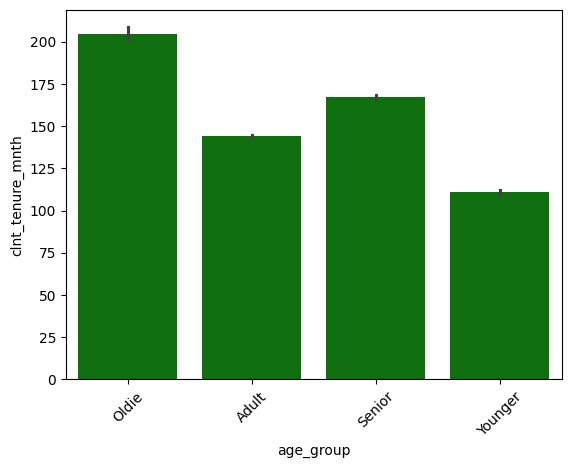

In [56]:
sns.barplot(x='age_group', y='clnt_tenure_mnth', data=df, color='green')
plt.xticks(rotation=45)
plt.tight_layout
plt.show

In [57]:
df_wd1.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [58]:
web = pd.concat([df_wd1, df_wd2], ignore_index=True) # Combine the two web data files into one dataframe.

In [59]:
web.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [60]:
web.shape

(755405, 5)

In [61]:
web.groupby('client_id')['process_step'].count().reset_index()


,client_id,process_step
0,169,5
1,336,2
2,546,5
3,555,5
4,647,5
...,...,...
120152,9999729,11
120153,9999768,12
120154,9999832,2
120155,9999839,6


In [62]:
from functions import process_step_counts
process_step_counts()


,process_step,count
0,start,243945
1,step_1,163193
2,step_2,133062
3,step_3,112242
4,confirm,102963


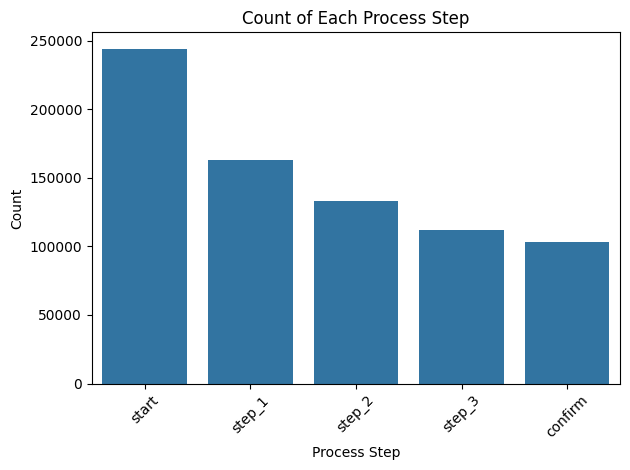

In [63]:
sns.barplot(x='process_step', y='count', data=process_step_counts())
plt.xticks(rotation=45)
plt.title('Count of Each Process Step')
plt.xlabel('Process Step')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [64]:
web.groupby("visit_id")["process_step"].count().reset_index()

,visit_id,process_step
0,100012776_37918976071_457913,2
1,1000165_4190026492_760066,5
2,100019538_17884295066_43909,11
3,100022086_87870757897_149620,5
4,100030127_47967100085_936361,1
...,...,...
158090,999986292_55082159911_561557,2
158091,999988789_76411676596_272843,5
158092,999989069_52203656268_170206,2
158093,999991142_15352368745_399725,1
